# Modelo 2 — Clasificador OCT con segmentación previa

In [1]:
descargar_dataset_completo = False

In [2]:
import os
from pathlib import Path

if descargar_dataset_completo:
    import kagglehub

    # Setea la carpeta data como default para almacenar los datasets descargados
    os.environ["KAGGLEHUB_CACHE"] = "./data"

    # ── Rutas ──────────────────────────────────────────────────────────────
    output_dir = os.path.abspath('./data/datasets/paultimothymooney/kermany2018/versions/2')
    dir_kaggle_clas = 'paultimothymooney/kermany2018'

    if os.access(output_dir, os.F_OK) is False:
        path = kagglehub.dataset_download(dir_kaggle_clas)
        output_dir = os.path.abspath(path)
    else:
        print('El dataset COMPLETO ya ha sido descargado previamente.')

else:

    import gdown
    import zipfile

    output_zip = 'data/oct_sample.zip'
    output_dir = 'data/oct_sample' # Nombre de la carpeta de destino

    if os.access(output_dir, os.F_OK) is False:
        os.makedirs(output_dir, exist_ok=True)
        gdown.download(id='1aISyF0gnHq4QJzWXY-AOwrOoPbljaOTF', output=output_zip, quiet=False, fuzzy=True)

        if os.path.exists(output_zip):
            # Descomprimir el archivo
            print(f"Descomprimiendo {output_zip}...")
            with zipfile.ZipFile(output_zip, 'r') as zip_ref:
                zip_ref.extractall(output_dir)

            # Opcional: Eliminar el archivo .zip para ahorrar espacio
            os.remove(output_zip)
            print(f"Archivos extraídos en la carpeta: '{output_dir}'")
        else:
            print("Error: No se pudo encontrar el archivo descargado. Revisa los permisos del link.")
    else:
        print('El dataset MUESTRA ya ha sido descargado previamente.')

Downloading...
From (original): https://drive.google.com/uc?id=1aISyF0gnHq4QJzWXY-AOwrOoPbljaOTF
From (redirected): https://drive.google.com/uc?id=1aISyF0gnHq4QJzWXY-AOwrOoPbljaOTF&confirm=t&uuid=8e81ac86-3d83-4fcb-bc69-e35937b25c54
To: /content/data/oct_sample.zip
100%|██████████| 937M/937M [00:31<00:00, 30.2MB/s]


Descomprimiendo data/oct_sample.zip...
Archivos extraídos en la carpeta: 'data/oct_sample'


In [3]:
pip install segmentation_models_pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 9.7 MB/s eta 0:00:00


In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader, Dataset
import segmentation_models_pytorch as smp
from PIL import Image
import numpy as np


device = 'cuda' if torch.cuda.is_available() else 'cpu'

TRAIN_PATH  =  Path(os.path.join(output_dir,"OCT2017 /train"))
VAL_PATH   = Path(os.path.join(output_dir,"OCT2017 /val"))
TEST_PATH   = Path(os.path.join(output_dir,"OCT2017 /test"))

print(f"Ruta de las imágenes TRAIN: {TRAIN_PATH}")
print(f"Ruta de las imágenes VAL: {VAL_PATH}")
print(f"Ruta de las imágenes TEST: {TEST_PATH}")

Ruta de las imágenes TRAIN: data/oct_sample/OCT2017 /train
Ruta de las imágenes VAL: data/oct_sample/OCT2017 /val
Ruta de las imágenes TEST: data/oct_sample/OCT2017 /test


In [5]:
weights_dir = 'modelos'
weights_path = os.path.join(weights_dir, 'unetpp_smp_finetunning.pth')
if not os.path.exists(weights_path):
    os.makedirs(weights_dir, exist_ok=True)

    import gdown
    gdown.download(id='1qLXEMAwxmAgUEj6ZXRfra29g3zyf3jVp',
               output=weights_path,
               fuzzy=True)
else:
    print('Pesos del modelo segmentador ya descargados')


!ls -R /content/modelos

print(os.path.exists(weights_path))
print(os.path.getsize(weights_path))

Downloading...
From (original): https://drive.google.com/uc?id=1qLXEMAwxmAgUEj6ZXRfra29g3zyf3jVp
From (redirected): https://drive.google.com/uc?id=1qLXEMAwxmAgUEj6ZXRfra29g3zyf3jVp&confirm=t&uuid=a910cd1f-c190-4cc9-bfdf-61bda872456a
To: /content/modelos/unetpp_smp_finetunning.pth
100%|██████████| 105M/105M [00:02<00:00, 42.2MB/s] 

/content/modelos:
unetpp_smp_finetunning.pth
True
104507999


In [6]:
# ── Carga del modelo de segmentación ──────────────────────────────────
# El modelo es UNet++ con encoder ResNet34, 1 canal entrada, 8 clases de salida.
# Guardado con torch.save(model.state_dict(), ...)

import segmentation_models_pytorch as smp

seg_model = smp.UnetPlusPlus(
    encoder_name='resnet34',
    encoder_weights=None,   # no cargar imagenet, vamos a cargar nuestros pesos
    in_channels=1,
    classes=8
)

import os
size = os.path.getsize('modelos/unetpp_smp_finetunning.pth')
print(f"{size / 1024 / 1024:.1f} MB")  # debe decir ~99.6 MB

seg_model.load_state_dict(torch.load(weights_path, map_location=device))
seg_model.to(device)
seg_model.eval()

# Congelar: no queremos que se entrene junto con el clasificador
for param in seg_model.parameters():
    param.requires_grad = False

print('Modelo de segmentación cargado y congelado.')

99.7 MB
Modelo de segmentación cargado y congelado.


In [15]:
# ── Dataset con segmentación on-the-fly ───────────────────────────────
# Pipeline por imagen:
#   1. Cargar imagen OCT (RGB desde ImageFolder)
#   2. Convertir a escala de grises (1 canal) → pasar por seg_model
#   3. La máscara resultante (valores 0-7) se normaliza a [0,1] y se
#      repite en 3 canales para que sea compatible con ResNet50
#   4. Aplicar normalización ImageNet

from torch.utils.data import Subset, WeightedRandomSampler
class SegmentedDataset(Dataset):
    def __init__(self, folder_path, seg_model, augment=False):
        self.base_ds   = datasets.ImageFolder(folder_path)
        self.seg_model = seg_model
        self.augment   = augment
        self.classes   = self.base_ds.classes

        # Pre-procesado para el modelo de segmentación
        # UNet++ espera (1, H, W) normalizado [0,1]
        self.to_seg = transforms.Compose([
            transforms.Resize((224, 512)),   # mismo tamaño usado en entrenamiento del segmentador
            transforms.Grayscale(num_output_channels=1),
            transforms.ToTensor(),           # [0,1]
        ])

        # Post-procesado: la máscara se normaliza y pasa a 3 canales
        self.post = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.Normalize([0.485, 0.456, 0.406],
                                  [0.229, 0.224, 0.225]),
        ])

        self.aug = transforms.Compose([
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
        ]) if augment else nn.Identity()

        # Pre-procesado para el clasificador: RGB -> tensor 3ch, 224x224 + normalización ImageNet
        self.to_cls = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406],
                                [0.229, 0.224, 0.225]),
        ])


    def __len__(self):
        return len(self.base_ds)

    def __getitem__(self, idx):
        img_path, label = self.base_ds.imgs[idx]
        img_pil = Image.open(img_path).convert('RGB')

        # 1) Imagen cruda para el clasificador (3,224,224) normalizada ImageNet
        img_3c = self.to_cls(img_pil)            # tensor (3,224,224)

        # 2) Input para segmentador (1,224,512)
        x_seg = self.to_seg(img_pil).unsqueeze(0).to(device)  # (1,1,224,512)

        # 3) Inferencia del segmentador → máscara (224,512) con valores 0-7
        with torch.no_grad():
            logits = self.seg_model(x_seg)                 # (1,8,224,512)
            mask   = logits.argmax(dim=1).squeeze(0)       # (224,512)

        # 4) Máscara -> float [0,1] -> (1,224,512) -> resize a (1,224,224)
        mask_f  = (mask.float() / 7.0).unsqueeze(0)        # (1,224,512)
        mask_1c = F.interpolate(mask_f.unsqueeze(0), size=(224, 224), mode='nearest').squeeze(0)
        # mask_1c: (1,224,224)

        # 5) Augmentación *coherente* entre imagen y máscara (mínimo: flips)
        if self.augment:
            if torch.rand(1).item() < 0.5:
                img_3c = torch.flip(img_3c, dims=[2])      # flip W
                mask_1c = torch.flip(mask_1c, dims=[2])
            if torch.rand(1).item() < 0.5:
                img_3c = torch.flip(img_3c, dims=[1])      # flip H
                mask_1c = torch.flip(mask_1c, dims=[1])

        # 6) Concatenar: (3 + 1) canales = (4,224,224)
        x_4c = torch.cat([img_3c, mask_1c.cpu()], dim=0)

        return x_4c, label


train_ds = SegmentedDataset(TRAIN_PATH, seg_model, augment=True)
val_ds   = SegmentedDataset(VAL_PATH,   seg_model, augment=False)
test_ds  = SegmentedDataset(TEST_PATH,  seg_model, augment=False)

class_counts = torch.bincount(torch.tensor(train_ds.base_ds.targets))
weights = 1.0 / class_counts.float()
sample_weights = weights[train_ds.base_ds.targets]

sampler = WeightedRandomSampler(sample_weights, num_samples=8000, replacement=True)

train_loader = DataLoader(train_ds, batch_size=32, sampler=sampler)
val_loader   = DataLoader(val_ds,   batch_size=16, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=16, shuffle=False, num_workers=0)

print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')
print(f'Clases: {train_ds.classes}')

Train: 8003 | Val: 2032 | Test: 4015
Clases: ['CNV', 'DME', 'DRUSEN', 'NORMAL']


In [16]:
print('\nNúmero de imágenes por clase en TRAIN loader:')
class_counts_train = {class_name: 0 for class_name in train_ds.classes}
for _, labels in train_loader:
    for label in labels:
        class_counts_train[train_ds.classes[label.item()]] += 1
for class_name, count in class_counts_train.items():
    print(f'  {class_name}: {count}')

print('\nNúmero de imágenes por clase en TEST loader:')
class_counts_test = {class_name: 0 for class_name in test_ds.classes}
for _, labels in test_loader:
    for label in labels:
        class_counts_test[test_ds.classes[label.item()]] += 1
for class_name, count in class_counts_test.items():
    print(f'  {class_name}: {count}')

print('\nNúmero de imágenes por clase en VAL loader:')
class_counts_val = {class_name: 0 for class_name in val_ds.classes}
for _, labels in val_loader:
    for label in labels:
        class_counts_val[val_ds.classes[label.item()]] += 1
for class_name, count in class_counts_val.items():
    print(f'  {class_name}: {count}')


Número de imágenes por clase en TRAIN loader:
  CNV: 1932
  DME: 1984
  DRUSEN: 2053
  NORMAL: 2031

Número de imágenes por clase en TEST loader:
  CNV: 990
  DME: 1002
  DRUSEN: 1021
  NORMAL: 1002

Número de imágenes por clase en VAL loader:
  CNV: 508
  DME: 508
  DRUSEN: 508
  NORMAL: 508


In [17]:
# ── Modelo clasificador ───────────────────────────────────────────────

model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

old_conv = model.conv1
model.conv1 = nn.Conv2d(
    in_channels=4,
    out_channels=old_conv.out_channels,
    kernel_size=old_conv.kernel_size,
    stride=old_conv.stride,
    padding=old_conv.padding,
    bias=old_conv.bias is not None
)

with torch.no_grad():
    # old_conv.weight: (64,3,7,7)
    w = old_conv.weight.mean(dim=1, keepdim=True)     # (64,1,7,7)
    model.conv1.weight[:, 0:3, :, :] = old_conv.weight
    model.conv1.weight[:, 3:4, :, :] = w              # canal extra (máscara) inicializado razonablemente

model.fc = nn.Linear(model.fc.in_features, 4)
model.to(device)


# ── Loss + optimizer ──────────────────────────────────────────────────
loss_fn   = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
epochs     = 20
patience   = 5
best_val   = float('inf')
bad_epochs = 0

best_path = 'retina-oct-demo-app/weights/modelo3_raw_seg_resnet50.pth'

In [ ]:
# ── Train loop ────────────────────────────────────────────────────────
from tqdm import tqdm

for epoch in range(epochs):

    # ── train ──
    model.train()
    train_loss = 0.0

    for x, y in tqdm(train_loader, desc=f'Epoch {epoch+1} train'):
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss   = loss_fn(logits, y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ── val ──
    model.eval()
    val_loss    = 0.0
    val_correct = 0

    with torch.no_grad():
        for x, y in val_loader:
            x, y   = x.to(device), y.to(device)
            logits = model(x)
            val_loss    += loss_fn(logits, y).item()
            val_correct += (logits.argmax(dim=1) == y).sum().item()

    val_loss /= len(val_loader)
    val_acc   = val_correct / len(val_loader.dataset)

    print(f'Epoch {epoch+1}/{epochs} - train loss: {train_loss:.4f} - val loss: {val_loss:.4f} - val acc: {val_acc:.4f}')

    # ── early stopping ──
    if val_loss < best_val - 1e-6:
        best_val   = val_loss
        bad_epochs = 0
        torch.save(model.state_dict(), best_path)
        print(f'  ✅ Mejoró val_loss. Guardado en {best_path}')
    else:
        bad_epochs += 1
        print(f'  ⏳ No mejoró. patience: {bad_epochs}/{patience}')

        if bad_epochs >= patience:
            print(f'🛑 Early stopping: {patience} épocas sin mejora.')
            break

print('Entrenamiento finalizado.')

Epoch 1 train: 100%|██████████| 250/250 [04:52<00:00,  1.17s/it]


Epoch 1/20 - train loss: 0.3728 - val loss: 0.2884 - val acc: 0.9163
  ✅ Mejoró val_loss. Guardado en modelos/modelo3_raw_seg_resnet50.pth


Epoch 2 train: 100%|██████████| 250/250 [04:50<00:00,  1.16s/it]


Epoch 2/20 - train loss: 0.1245 - val loss: 0.1870 - val acc: 0.9365
  ✅ Mejoró val_loss. Guardado en modelos/modelo3_raw_seg_resnet50.pth


Epoch 3 train: 100%|██████████| 250/250 [04:49<00:00,  1.16s/it]


...

Epoch 5/20 - train loss: 0.0604 - val loss: 0.3112 - val acc: 0.9262
  ⏳ No mejoró. patience: 3/5


Epoch 6 train: 100%|██████████| 250/250 [04:50<00:00,  1.16s/it]


Epoch 6/20 - train loss: 0.0495 - val loss: 0.2692 - val acc: 0.9281
  ⏳ No mejoró. patience: 4/5


Epoch 7 train: 100%|██████████| 250/250 [04:52<00:00,  1.17s/it]


Epoch 7/20 - train loss: 0.0336 - val loss: 0.4401 - val acc: 0.9227
  ⏳ No mejoró. patience: 5/5
🛑 Early stopping: 5 épocas sin mejora.
Entrenamiento finalizado.


              precision    recall  f1-score   support

         CNV       0.89      0.99      0.93       990
         DME       0.93      0.93      0.93      1002
      DRUSEN       0.95      0.83      0.89      1021
      NORMAL       0.91      0.93      0.92      1002

    accuracy                           0.92      4015
   macro avg       0.92      0.92      0.92      4015
weighted avg       0.92      0.92      0.92      4015



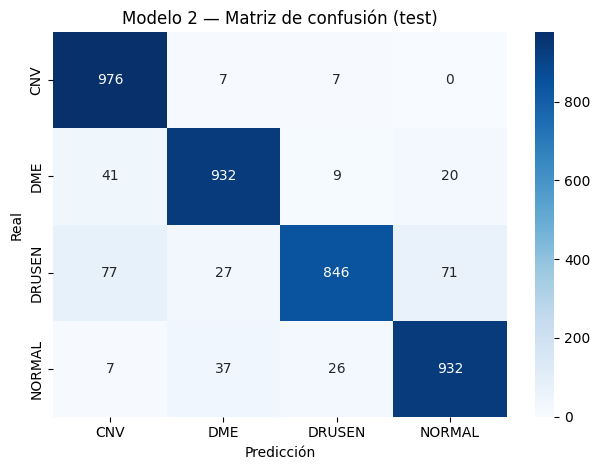

In [19]:
# ── Evaluación en test ────────────────────────────────────────────────
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

model.load_state_dict(torch.load(best_path, map_location=device))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        all_preds.extend(model(x).argmax(dim=1).cpu().numpy())
        all_labels.extend(y.numpy())

class_names = ['CNV', 'DME', 'DRUSEN', 'NORMAL']
print(classification_report(all_labels, all_preds, target_names=class_names))

cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Modelo 2 — Matriz de confusión (test)')
plt.ylabel('Real')
plt.xlabel('Predicción')
plt.tight_layout()
plt.show()